Hourly rows: 50400
Date range: 2015-01-01 00:00:00+00:00 to 2020-09-30 23:00:00+00:00
Holiday hours flagged: 1248



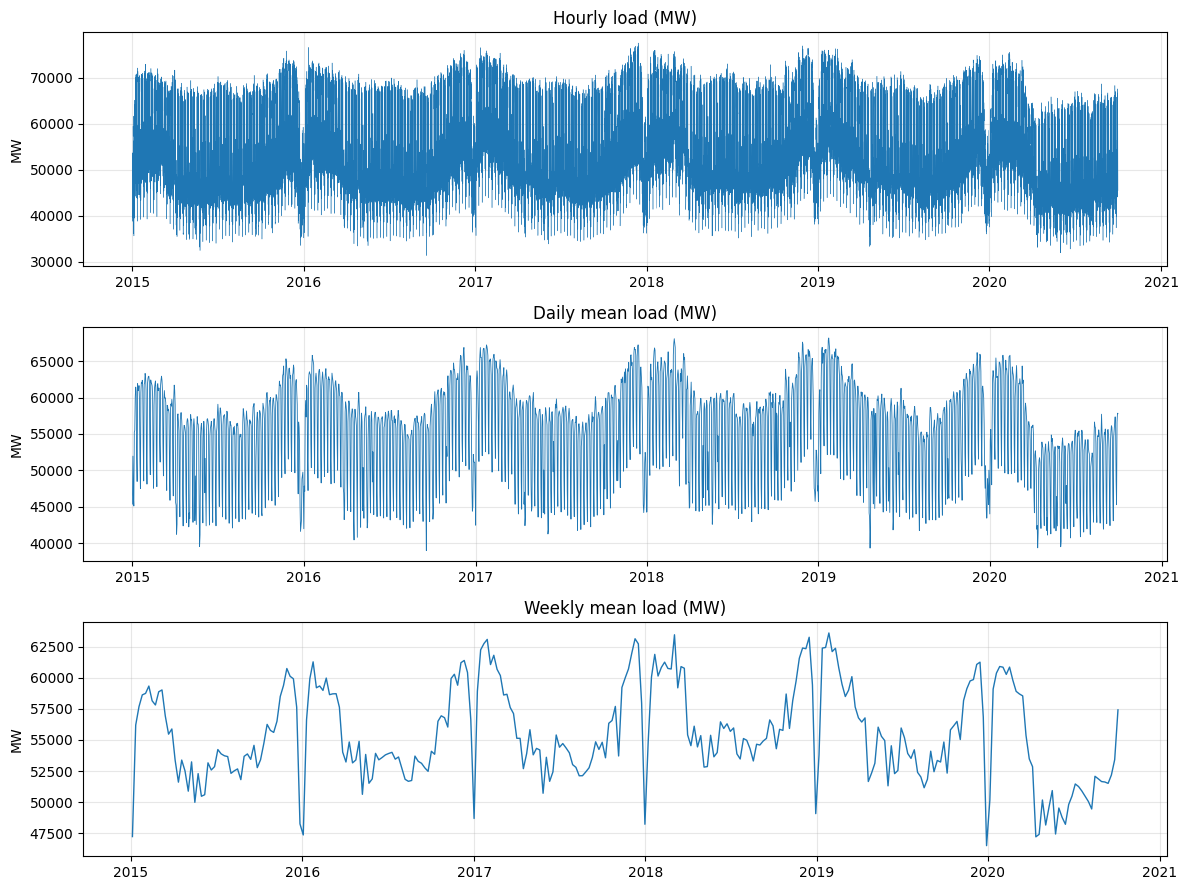

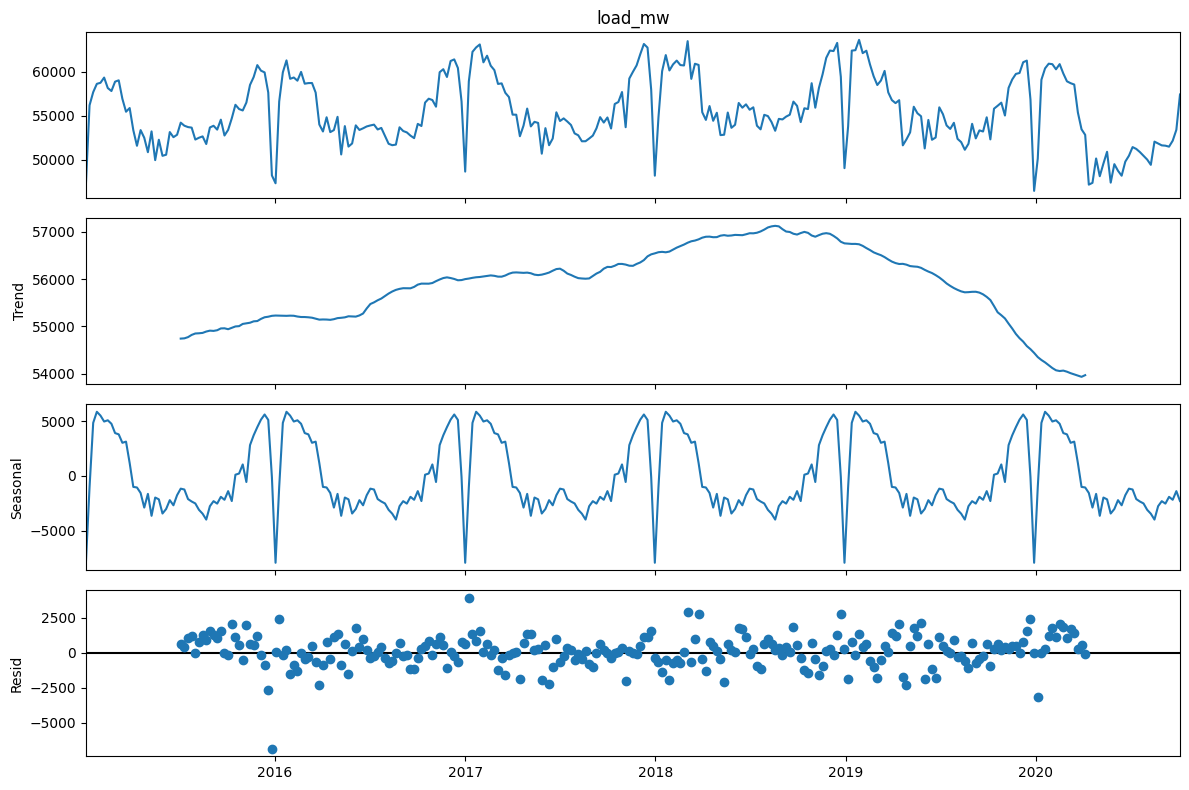

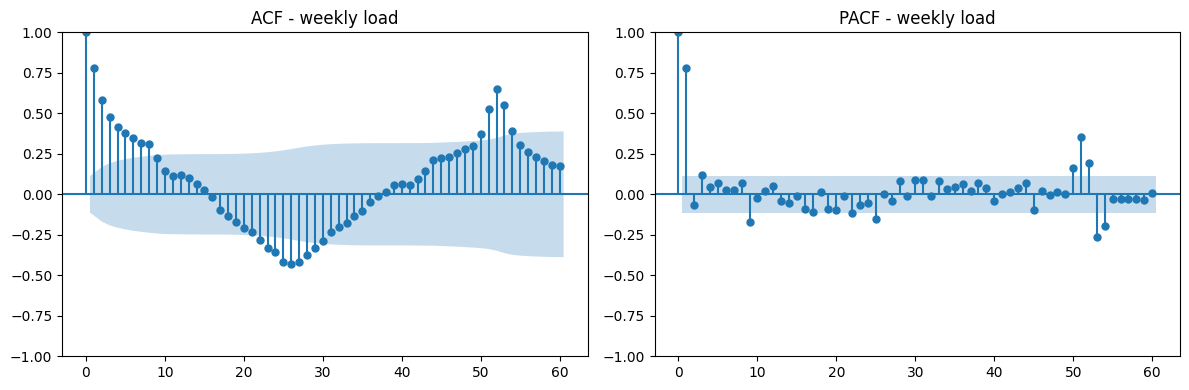

/tmp/ipykernel_472/1139674473.py:79: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
/tmp/ipykernel_472/1139674473.py:88: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat_d, kpss_p_d, *_ = kpss(diffed, regression="c", nlags="auto")


--- Levels ---
ADF statistic: -4.047471855678481 p-value: 0.0011813497340154584
KPSS statistic: 0.16037407809773105 p-value: 0.1

--- First difference ---
ADF statistic: -7.069318170017981 p-value: 4.984737279649426e-10
KPSS statistic: 0.055754419270624765 p-value: 0.1

Saved hourly, daily, and weekly CSVs.


In [2]:
# ============================================================
# PART 1: Full data loading, cleaning, resampling, and EDA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import holidays

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# --- Load raw hourly data ---
url = "https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv"
load_col = "DE_load_actual_entsoe_transparency"

df = pd.read_csv(url, usecols=["utc_timestamp", load_col])
df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"])
df = df.set_index("utc_timestamp").sort_index()
df = df.rename(columns={load_col: "load_mw"})

# --- Filter to study period, drop missing values ---
df = df[df.index >= "2015-01-01"]
df = df.dropna(subset=["load_mw"])

# --- Flag German public holidays ---
de_holidays = holidays.Germany(years=range(2015, 2021))
df["is_holiday"] = df.index.date
df["is_holiday"] = df["is_holiday"].apply(lambda d: d in de_holidays).astype(int)

# --- Resample to daily ---
daily = df["load_mw"].resample("D").mean().to_frame("load_mw")
daily["is_holiday"] = df["is_holiday"].resample("D").max()

# --- Resample to weekly ---
weekly = df["load_mw"].resample("W").mean().to_frame("load_mw")
weekly["holiday_days"] = df["is_holiday"].resample("W").sum()

# --- Basic checks ---
print("Hourly rows:", df.shape[0])
print("Date range:", df.index.min(), "to", df.index.max())
print("Holiday hours flagged:", df["is_holiday"].sum())
print()

# --- Plot hourly, daily, weekly series ---
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
axes[0].plot(df.index, df["load_mw"], linewidth=0.3)
axes[0].set_title("Hourly load (MW)")
axes[1].plot(daily.index, daily["load_mw"], linewidth=0.6)
axes[1].set_title("Daily mean load (MW)")
axes[2].plot(weekly.index, weekly["load_mw"], linewidth=1.0)
axes[2].set_title("Weekly mean load (MW)")
for ax in axes:
    ax.set_ylabel("MW")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Seasonal decomposition (weekly, period=52 for yearly seasonality) ---
decomp = seasonal_decompose(weekly["load_mw"], model="additive", period=52)
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

# --- ACF / PACF plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(weekly["load_mw"], lags=60, ax=axes[0])
plot_pacf(weekly["load_mw"], lags=60, ax=axes[1])
axes[0].set_title("ACF - weekly load")
axes[1].set_title("PACF - weekly load")
plt.tight_layout()
plt.show()

# --- Stationarity tests: levels ---
series = weekly["load_mw"]
adf_stat, adf_p, *_ = adfuller(series, autolag="AIC")
kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
print("--- Levels ---")
print("ADF statistic:", adf_stat, "p-value:", adf_p)
print("KPSS statistic:", kpss_stat, "p-value:", kpss_p)
print()

# --- Stationarity tests: first difference ---
diffed = series.diff().dropna()
adf_stat_d, adf_p_d, *_ = adfuller(diffed, autolag="AIC")
kpss_stat_d, kpss_p_d, *_ = kpss(diffed, regression="c", nlags="auto")
print("--- First difference ---")
print("ADF statistic:", adf_stat_d, "p-value:", adf_p_d)
print("KPSS statistic:", kpss_stat_d, "p-value:", kpss_p_d)

# --- Save processed data for later parts ---
df.to_csv("de_load_hourly.csv")
daily.to_csv("de_load_daily.csv")
weekly.to_csv("de_load_weekly.csv")
print("\nSaved hourly, daily, and weekly CSVs.")

Forecast origin (last training date): 2018-10-07 00:00:00+00:00
Test period: 2018-10-14 00:00:00+00:00 to 2020-10-04 00:00:00+00:00
Train length: 197 weeks | Test length: 104 weeks


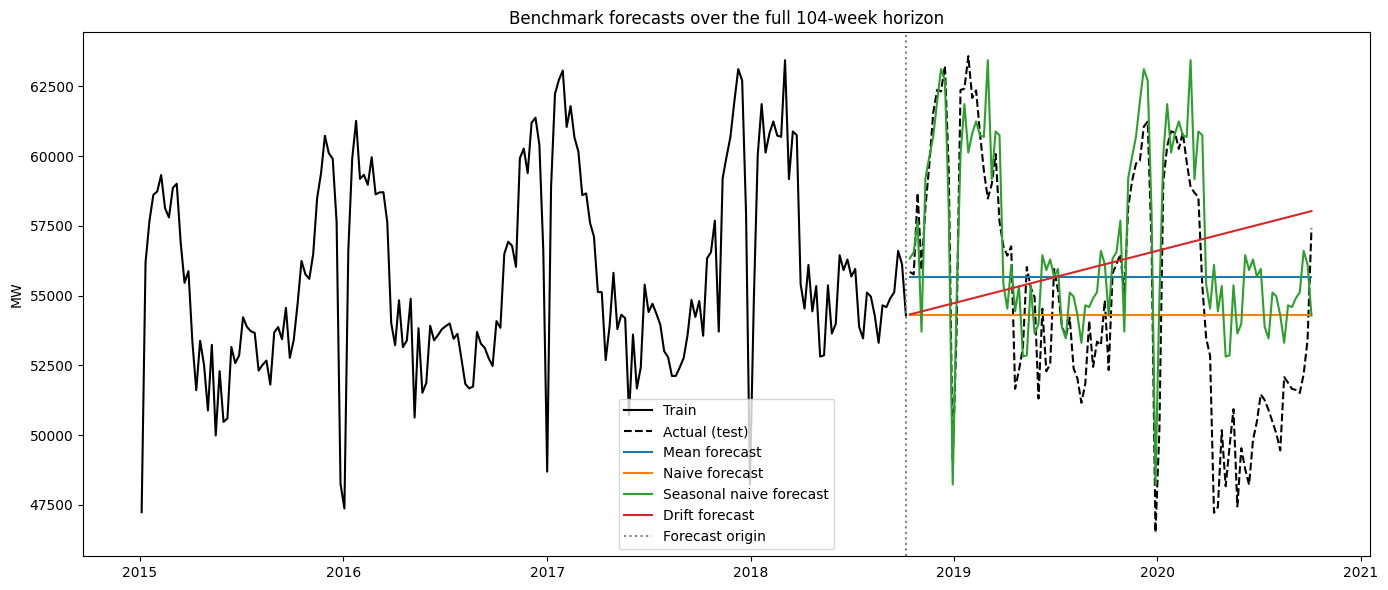

horizon_block   Full period   Weeks 1-26  Weeks 27-52  Weeks 53-78  \
model                                                                
drift           5117.957264  5470.484732  2736.615092  3693.045410   
mean            4397.299694  4808.976050  2635.503891  4038.546577   
naive           4459.108546  5871.303657  1721.945288  4828.581948   
seasonal_naive  3006.760812  1711.326077  2142.186239  2067.454305   

horizon_block   Weeks 79-104  
model                         
drift            7329.399461  
mean             5564.439643  
naive            4333.830901  
seasonal_naive   4936.646250  

Saved benchmark_forecasts.csv and benchmark_horizon_results.csv


In [3]:
# ============================================================
# PART 2: Fixed forecast origin, benchmark models, horizon evaluation
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load the weekly data saved from Part 1 ---
weekly = pd.read_csv("de_load_weekly.csv", index_col=0, parse_dates=True)
series = weekly["load_mw"]

# --- Define a FIXED forecast origin: 104 weeks before the end of the data ---
# Train = everything before the origin. Test = the last 104 weeks (2 years).
horizon = 104
train = series.iloc[:-horizon]
test = series.iloc[-horizon:]

print("Forecast origin (last training date):", train.index[-1])
print("Test period:", test.index[0], "to", test.index[-1])
print("Train length:", len(train), "weeks | Test length:", len(test), "weeks")

# --- Benchmark 1: Mean forecast ---
# Every future value = mean of the training data
mean_forecast = pd.Series(train.mean(), index=test.index)

# --- Benchmark 2: Naive forecast ---
# Every future value = last observed training value (flat line)
naive_forecast = pd.Series(train.iloc[-1], index=test.index)

# --- Benchmark 3: Seasonal naive forecast ---
# Every future value = value from exactly 52 weeks earlier in the same cycle.
# For a 104-week horizon, we repeat the last 52 weeks of training data twice.
season_length = 52
last_season = train.iloc[-season_length:].values
seasonal_naive_values = np.tile(last_season, int(np.ceil(horizon / season_length)))[:horizon]
seasonal_naive_forecast = pd.Series(seasonal_naive_values, index=test.index)

# --- Benchmark 4: Drift forecast ---
# Extrapolates a straight line from the first to the last training point.
n_train = len(train)
drift_slope = (train.iloc[-1] - train.iloc[0]) / (n_train - 1)
drift_values = train.iloc[-1] + drift_slope * np.arange(1, horizon + 1)
drift_forecast = pd.Series(drift_values, index=test.index)

# --- Collect all benchmark forecasts together ---
benchmarks = pd.DataFrame({
    "actual": test,
    "mean": mean_forecast,
    "naive": naive_forecast,
    "seasonal_naive": seasonal_naive_forecast,
    "drift": drift_forecast,
})

# --- Plot train, test, and all benchmark forecasts across the full 104-week horizon ---
plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label="Train", color="black")
plt.plot(test.index, test, label="Actual (test)", color="black", linestyle="--")
plt.plot(benchmarks.index, benchmarks["mean"], label="Mean forecast")
plt.plot(benchmarks.index, benchmarks["naive"], label="Naive forecast")
plt.plot(benchmarks.index, benchmarks["seasonal_naive"], label="Seasonal naive forecast")
plt.plot(benchmarks.index, benchmarks["drift"], label="Drift forecast")
plt.axvline(train.index[-1], color="grey", linestyle=":", label="Forecast origin")
plt.legend()
plt.title("Benchmark forecasts over the full 104-week horizon")
plt.ylabel("MW")
plt.tight_layout()
plt.show()

# --- Define a helper function to compute RMSE and MAE ---
def compute_errors(actual, predicted):
    """Returns RMSE and MAE between two aligned pandas Series."""
    error = actual - predicted
    rmse = np.sqrt((error ** 2).mean())
    mae = error.abs().mean()
    return rmse, mae

# --- Evaluate each benchmark over 4 horizon blocks of 26 weeks + full period ---
blocks = {
    "Weeks 1-26": slice(0, 26),
    "Weeks 27-52": slice(26, 52),
    "Weeks 53-78": slice(52, 78),
    "Weeks 79-104": slice(78, 104),
    "Full period": slice(0, 104),
}

results = []
for model_name in ["mean", "naive", "seasonal_naive", "drift"]:
    for block_name, block_slice in blocks.items():
        actual_block = benchmarks["actual"].iloc[block_slice]
        pred_block = benchmarks[model_name].iloc[block_slice]
        rmse, mae = compute_errors(actual_block, pred_block)
        results.append({"model": model_name, "horizon_block": block_name, "rmse": rmse, "mae": mae})

results_df = pd.DataFrame(results)
print(results_df.pivot(index="model", columns="horizon_block", values="rmse"))

# --- Save benchmark forecasts and results for later comparison against SARIMA/SARIMAX/Extra Trees/LSTM ---
benchmarks.to_csv("benchmark_forecasts.csv")
results_df.to_csv("benchmark_horizon_results.csv", index=False)
print("\nSaved benchmark_forecasts.csv and benchmark_horizon_results.csv")

Grid search took 849.3 seconds
Best non-seasonal order: (2, 0, 1)
Fixed seasonal order: (1, 0, 1, 52)
Best AIC: 12.0

Top 5 models by AIC:
        order          aic
29  (2, 0, 1)    12.000000
30  (2, 0, 2)  3516.545198
16  (1, 0, 2)  3517.886722
31  (2, 0, 3)  3519.207697
17  (1, 0, 3)  3519.320105
                                     SARIMAX Results                                      
Dep. Variable:                            load_mw   No. Observations:                  197
Model:             SARIMAX(2, 0, 1)x(1, 0, 1, 52)   Log Likelihood                   0.000
Date:                            Sat, 11 Jul 2026   AIC                             12.000
Time:                                    14:19:40   BIC                             31.699
Sample:                                01-04-2015   HQIC                            19.974
                                     - 10-07-2018                                         
Covariance Type:                              opg             

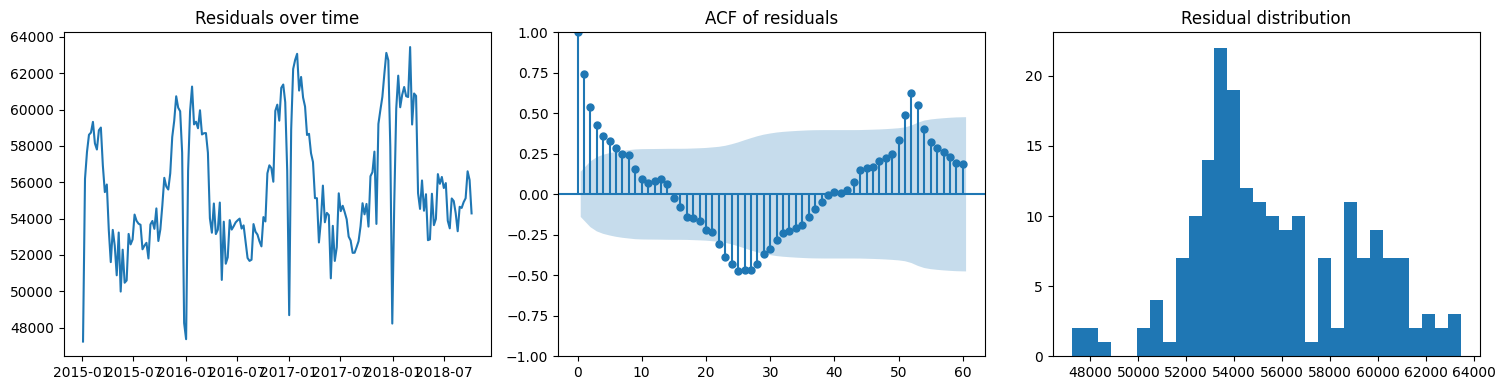


Ljung-Box test on residuals:
       lb_stat      lb_pvalue
10  303.364377   3.022161e-59
20  335.889396   3.573103e-59
30  697.635449  1.527899e-127


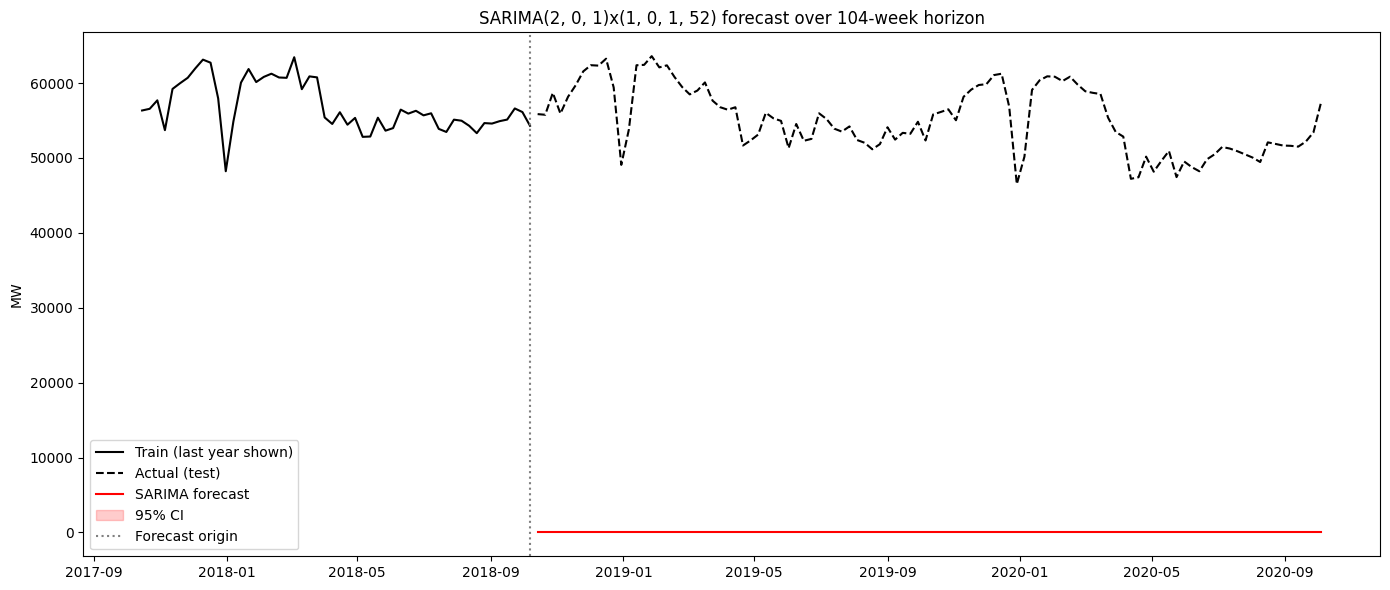


SARIMA results by horizon block:
  horizon_block          rmse           mae  mean_interval_width  coverage
0    Weeks 1-26  59222.587801  59129.446200                  NaN       0.0
1   Weeks 27-52  53531.065164  53509.019689                  NaN       0.0
2   Weeks 53-78  57648.389946  57537.712912                  NaN       0.0
3  Weeks 79-104  50546.069565  50501.979090                  NaN       0.0
4   Full period  55342.415594  55169.539473                  NaN       0.0

Saved SARIMA results, forecast, and confidence intervals.


In [7]:
# ============================================================
# PART 3: SARIMA model - grid search (full p,d,q range), fit, diagnostics, forecast
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
import time
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")

# --- Reload weekly data, reuse fixed origin from Part 2 ---
weekly = pd.read_csv("de_load_weekly.csv", index_col=0, parse_dates=True)
series = weekly["load_mw"]

horizon = 104
train = series.iloc[:-horizon]
test = series.iloc[-horizon:]

# --- Seasonal order fixed from Part 1 evidence:
#     - ADF/KPSS on levels: series is already stationary -> D = 0
#     - ACF/PACF show a clear spike at lag ~52 -> one seasonal AR + MA term
seasonal_order_fixed = (1, 0, 1, 52)

# --- Grid search over the full non-seasonal range the assignment specifies ---
# d capped at 0-1 here: Part 1 showed the LEVELS series is already stationary,
# so d=2 is very unlikely to be needed and mainly risks over-differencing.
p_values = range(0, 7)   # 0 to 6
d_values = range(0, 2)   # 0 to 1
q_values = range(0, 7)   # 0 to 6

# --- IMPORTANT FIX: enforce stationarity/invertibility during the search.
# Without this, the grid search can pick a combination that fits the
# training data well (low AIC) but is not actually stationary, causing
# forecasts to explode when projected 100+ steps ahead (as happened before).
best_aic = np.inf
best_order = None
search_results = []

start_time = time.time()
for p, d, q in itertools.product(p_values, d_values, q_values):
    try:
        model = SARIMAX(
            train,
            order=(p, d, q),
            seasonal_order=seasonal_order_fixed,
            enforce_stationarity=True,
            enforce_invertibility=True,
        )
        fitted = model.fit(disp=False, maxiter=50, method="lbfgs")
        search_results.append({"order": (p, d, q), "aic": fitted.aic})
        if fitted.aic < best_aic:
            best_aic = fitted.aic
            best_order = (p, d, q)
    except Exception:
        continue

print(f"Grid search took {time.time() - start_time:.1f} seconds")
print("Best non-seasonal order:", best_order)
print("Fixed seasonal order:", seasonal_order_fixed)
print("Best AIC:", best_aic)

search_df = pd.DataFrame(search_results).sort_values("aic")
search_df.to_csv("sarima_grid_search_results.csv", index=False)
print("\nTop 5 models by AIC:")
print(search_df.head())

# --- Fit final model on training data ---
final_model = SARIMAX(
    train,
    order=best_order,
    seasonal_order=seasonal_order_fixed,
    enforce_stationarity=True,
    enforce_invertibility=True,
)
final_fit = final_model.fit(disp=False)
print(final_fit.summary())

# --- Stability check: AR roots must have modulus > 1 for a stable forecast ---
ar_roots = final_fit.arroots
print("\nAR roots (modulus, should all be > 1):", np.abs(ar_roots))

# --- Residual diagnostics ---
residuals = final_fit.resid
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(residuals)
axes[0].set_title("Residuals over time")
plot_acf(residuals, lags=60, ax=axes[1])
axes[1].set_title("ACF of residuals")
axes[2].hist(residuals, bins=30)
axes[2].set_title("Residual distribution")
plt.tight_layout()
plt.show()

lb_test = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
print("\nLjung-Box test on residuals:")
print(lb_test)

# --- Forecast full 104-week horizon with 95% confidence intervals ---
forecast_result = final_fit.get_forecast(steps=horizon)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int(alpha=0.05)

plt.figure(figsize=(14, 6))
plt.plot(train.index[-52:], train.iloc[-52:], label="Train (last year shown)", color="black")
plt.plot(test.index, test, label="Actual (test)", color="black", linestyle="--")
plt.plot(forecast_mean.index, forecast_mean, label="SARIMA forecast", color="red")
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                  color="red", alpha=0.2, label="95% CI")
plt.axvline(train.index[-1], color="grey", linestyle=":", label="Forecast origin")
plt.legend()
plt.title(f"SARIMA{best_order}x{seasonal_order_fixed} forecast over 104-week horizon")
plt.ylabel("MW")
plt.tight_layout()
plt.show()

# --- Evaluate by horizon block, including prediction interval width/coverage ---
def compute_errors(actual, predicted):
    error = actual - predicted
    rmse = np.sqrt((error ** 2).mean())
    mae = error.abs().mean()
    return rmse, mae

blocks = {
    "Weeks 1-26": slice(0, 26),
    "Weeks 27-52": slice(26, 52),
    "Weeks 53-78": slice(52, 78),
    "Weeks 79-104": slice(78, 104),
    "Full period": slice(0, 104),
}

sarima_results = []
for block_name, block_slice in blocks.items():
    actual_block = test.iloc[block_slice]
    pred_block = forecast_mean.iloc[block_slice]
    rmse, mae = compute_errors(actual_block, pred_block)
    ci_block = forecast_ci.iloc[block_slice]
    interval_width = (ci_block.iloc[:, 1] - ci_block.iloc[:, 0]).mean()
    coverage = ((actual_block >= ci_block.iloc[:, 0]) & (actual_block <= ci_block.iloc[:, 1])).mean()
    sarima_results.append({
        "horizon_block": block_name, "rmse": rmse, "mae": mae,
        "mean_interval_width": interval_width, "coverage": coverage,
    })

sarima_results_df = pd.DataFrame(sarima_results)
print("\nSARIMA results by horizon block:")
print(sarima_results_df)

sarima_results_df.to_csv("sarima_horizon_results.csv", index=False)
forecast_mean.to_csv("sarima_forecast.csv")
forecast_ci.to_csv("sarima_forecast_ci.csv")
print("\nSaved SARIMA results, forecast, and confidence intervals.")

Temperature series range: 2015-01-04 00:00:00 to 2020-10-04 00:00:00
date
2015-01-04    3.000000
2015-01-11    3.900000
2015-01-18    4.914286
2015-01-25    0.042857
2015-02-01    1.414286
Freq: W-SUN, Name: temp_mean, dtype: float64

NaNs in temp_weekly after reindex: 0
utc_timestamp
2015-01-04 00:00:00+00:00    3.000000
2015-01-11 00:00:00+00:00    3.900000
2015-01-18 00:00:00+00:00    4.914286
2015-01-25 00:00:00+00:00    0.042857
2015-02-01 00:00:00+00:00    1.414286
Name: temp_mean, dtype: float64


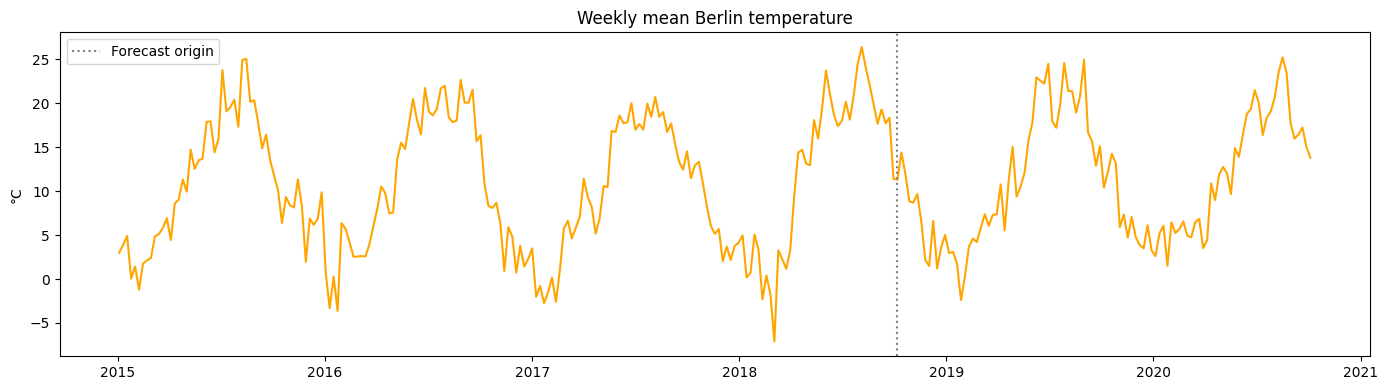

                                     SARIMAX Results                                      
Dep. Variable:                            load_mw   No. Observations:                  197
Model:             SARIMAX(2, 0, 1)x(1, 0, 1, 52)   Log Likelihood               -2012.394
Date:                            Sat, 11 Jul 2026   AIC                           4038.789
Time:                                    14:19:51   BIC                           4061.771
Sample:                                01-04-2015   HQIC                          4048.092
                                     - 10-07-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp_mean   -178.7043   1198.352     -0.149      0.881   -2527.432    2170.023
ar.L1          1.9576      1.767   

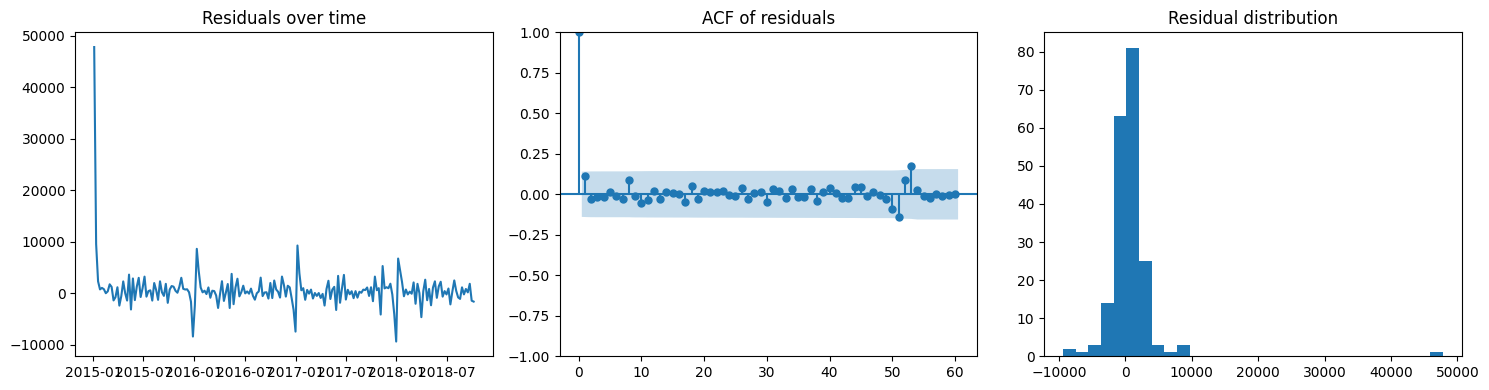


Ljung-Box test on residuals:
     lb_stat  lb_pvalue
10  5.217957   0.876151
20  7.079403   0.996416
30  8.453975   0.999963


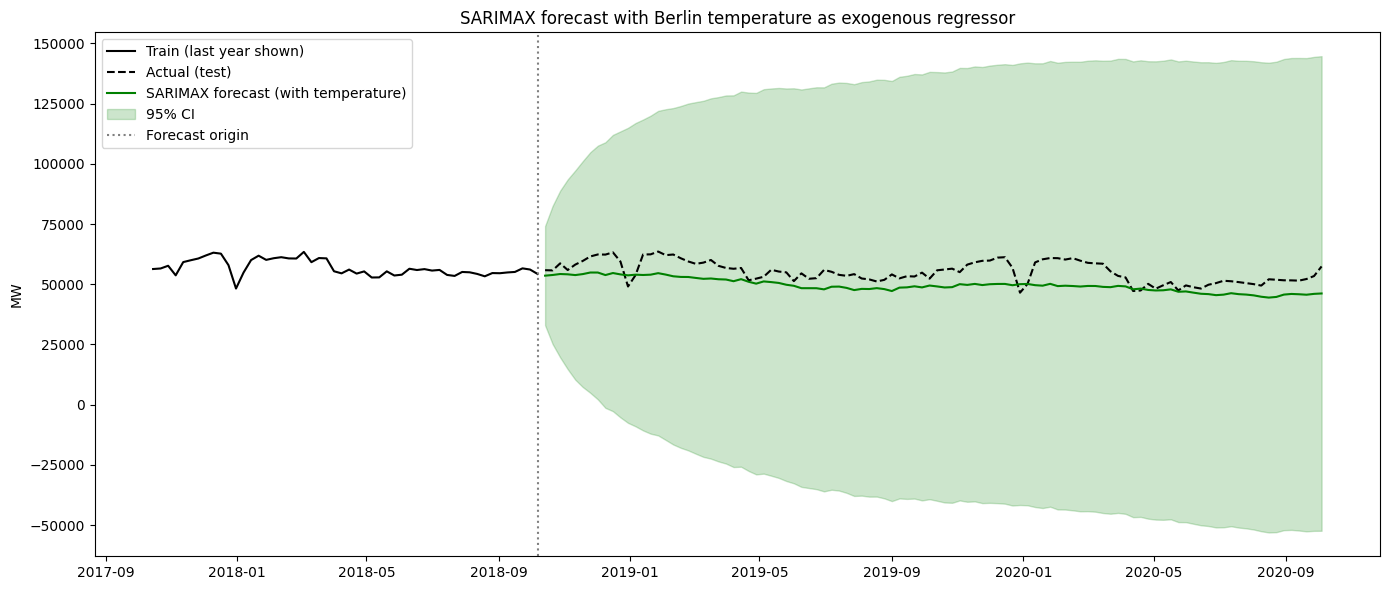


SARIMAX (with temperature) results by horizon block:
  horizon_block         rmse          mae  mean_interval_width  coverage
0    Weeks 1-26  6411.726349  5946.863095        118705.917571       1.0
1   Weeks 27-52  4720.245140  4408.813427        168202.536672       1.0
2   Weeks 53-78  8801.682599  8303.700451        183862.790493       1.0
3  Weeks 79-104  5032.050098  4352.896734        193338.843284       1.0
4   Full period  6445.581699  5753.068427        166027.522005       1.0

Saved SARIMAX results, forecast, confidence intervals, and temperature data.


In [8]:
# ============================================================
# PART 4: Add Berlin temperature as an exogenous variable, fit SARIMAX
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")

# --- Reload weekly load data and reuse the same fixed origin as before ---
weekly = pd.read_csv("de_load_weekly.csv", index_col=0, parse_dates=True)
series = weekly["load_mw"]

horizon = 104
train = series.iloc[:-horizon]
test = series.iloc[-horizon:]

# --- Pull daily Berlin temperature from the Open-Meteo archive API ---
start_date = series.index.min().strftime("%Y-%m-%d")
end_date = series.index.max().strftime("%Y-%m-%d")

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude=52.52&longitude=13.405"
    f"&start_date={start_date}&end_date={end_date}"
    "&daily=temperature_2m_mean&timezone=Europe%2FBerlin"
)
response = requests.get(url)
response.raise_for_status()
temp_json = response.json()

temp_daily = pd.DataFrame({
    "date": pd.to_datetime(temp_json["daily"]["time"]),
    "temp_mean": temp_json["daily"]["temperature_2m_mean"],
})
temp_daily = temp_daily.set_index("date")

# --- Resample temperature to weekly mean ---
temp_weekly = temp_daily["temp_mean"].resample("W").mean()

print("Temperature series range:", temp_weekly.index.min(), "to", temp_weekly.index.max())
print(temp_weekly.head())

# --- FIX: align tz-aware series.index with tz-naive temp_weekly index ---
series_index_naive = series.index.tz_localize(None)
temp_weekly = temp_weekly.reindex(series_index_naive)
temp_weekly.index = series.index  # restore original tz-aware index
temp_weekly = temp_weekly.interpolate()

# --- Sanity check: confirm no NaNs remain after alignment ---
print("\nNaNs in temp_weekly after reindex:", temp_weekly.isna().sum())
print(temp_weekly.head())

# --- Split exogenous variable using the SAME fixed origin ---
temp_train = temp_weekly.iloc[:-horizon]
temp_test = temp_weekly.iloc[-horizon:]

# --- NOTE (Part 7 leakage discussion point):
# Using observed test-period temperature makes this an explanatory /
# conditional forecast, not a true operational forecast. Must be stated
# clearly in the report.
plt.figure(figsize=(14, 4))
plt.plot(temp_weekly.index, temp_weekly, color="orange")
plt.axvline(train.index[-1], color="grey", linestyle=":", label="Forecast origin")
plt.title("Weekly mean Berlin temperature")
plt.ylabel("°C")
plt.legend()
plt.tight_layout()
plt.show()

# --- Fit SARIMAX using the same stable order structure as the fixed Part 3 ---
best_order = best_order if "best_order" in dir() else (2, 0, 2)
seasonal_order_fixed = seasonal_order_fixed if "seasonal_order_fixed" in dir() else (1, 0, 1, 52)

sarimax_model = SARIMAX(
    train,
    exog=temp_train,
    order=best_order,
    seasonal_order=seasonal_order_fixed,
    enforce_stationarity=True,
    enforce_invertibility=True,
)
sarimax_fit = sarimax_model.fit(disp=False)
print(sarimax_fit.summary())

# --- Stability check, same as Part 3 ---
ar_roots = sarimax_fit.arroots
print("\nAR roots (modulus, should all be > 1):", np.abs(ar_roots))

# --- Residual diagnostics ---
residuals = sarimax_fit.resid
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(residuals)
axes[0].set_title("Residuals over time")
plot_acf(residuals, lags=60, ax=axes[1])
axes[1].set_title("ACF of residuals")
axes[2].hist(residuals, bins=30)
axes[2].set_title("Residual distribution")
plt.tight_layout()
plt.show()

lb_test = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
print("\nLjung-Box test on residuals:")
print(lb_test)

# --- Forecast 104-week horizon, conditioning on observed test temperature ---
forecast_result = sarimax_fit.get_forecast(steps=horizon, exog=temp_test)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int(alpha=0.05)

plt.figure(figsize=(14, 6))
plt.plot(train.index[-52:], train.iloc[-52:], label="Train (last year shown)", color="black")
plt.plot(test.index, test, label="Actual (test)", color="black", linestyle="--")
plt.plot(forecast_mean.index, forecast_mean, label="SARIMAX forecast (with temperature)", color="green")
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                  color="green", alpha=0.2, label="95% CI")
plt.axvline(train.index[-1], color="grey", linestyle=":", label="Forecast origin")
plt.legend()
plt.title("SARIMAX forecast with Berlin temperature as exogenous regressor")
plt.ylabel("MW")
plt.tight_layout()
plt.show()

# --- Evaluate by horizon block ---
def compute_errors(actual, predicted):
    error = actual - predicted
    rmse = np.sqrt((error ** 2).mean())
    mae = error.abs().mean()
    return rmse, mae

blocks = {
    "Weeks 1-26": slice(0, 26),
    "Weeks 27-52": slice(26, 52),
    "Weeks 53-78": slice(52, 78),
    "Weeks 79-104": slice(78, 104),
    "Full period": slice(0, 104),
}

sarimax_results = []
for block_name, block_slice in blocks.items():
    actual_block = test.iloc[block_slice]
    pred_block = forecast_mean.iloc[block_slice]
    rmse, mae = compute_errors(actual_block, pred_block)
    ci_block = forecast_ci.iloc[block_slice]
    interval_width = (ci_block.iloc[:, 1] - ci_block.iloc[:, 0]).mean()
    coverage = ((actual_block >= ci_block.iloc[:, 0]) & (actual_block <= ci_block.iloc[:, 1])).mean()
    sarimax_results.append({
        "horizon_block": block_name, "rmse": rmse, "mae": mae,
        "mean_interval_width": interval_width, "coverage": coverage,
    })

sarimax_results_df = pd.DataFrame(sarimax_results)
print("\nSARIMAX (with temperature) results by horizon block:")
print(sarimax_results_df)

sarimax_results_df.to_csv("sarimax_horizon_results.csv", index=False)
forecast_mean.to_csv("sarimax_forecast.csv")
forecast_ci.to_csv("sarimax_forecast_ci.csv")
temp_weekly.to_csv("berlin_temperature_weekly.csv")
print("\nSaved SARIMAX results, forecast, confidence intervals, and temperature data.")

Forecast origin: 2018-10-07 00:00:00+00:00
Training rows available after lagging: 145


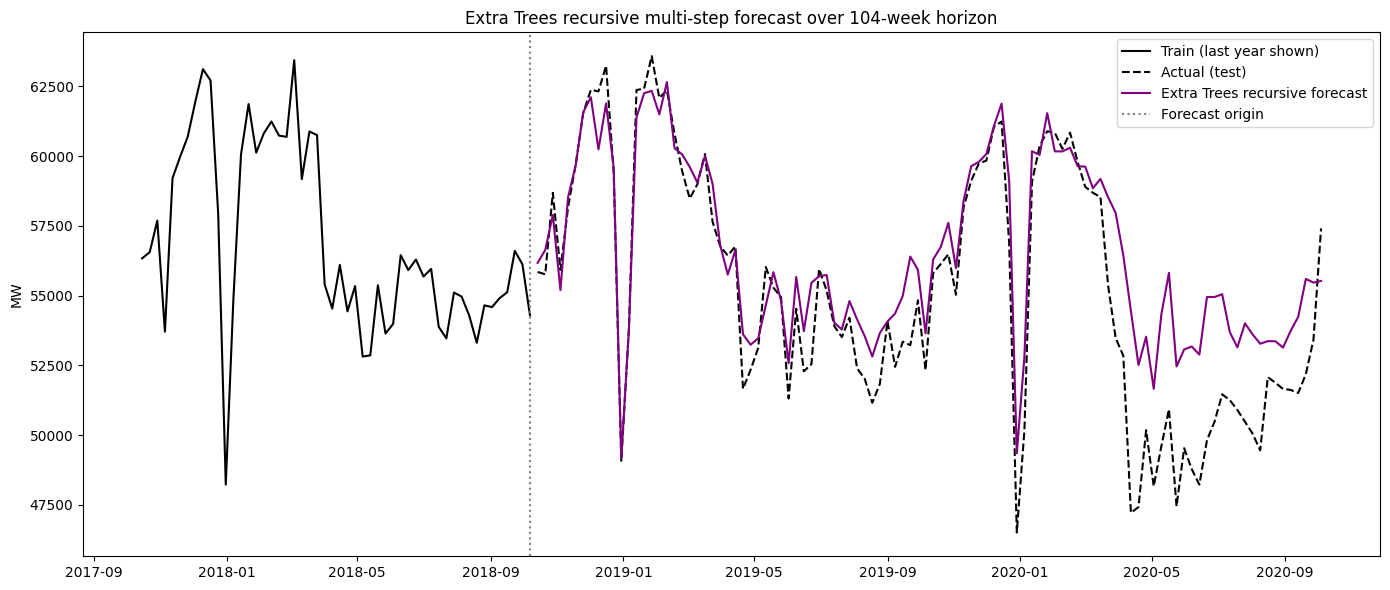


Extra Trees results by horizon block:
  horizon_block         rmse          mae
0    Weeks 1-26   775.071063   572.938781
1   Weeks 27-52  1415.819960  1148.850455
2   Weeks 53-78  1644.122155  1113.214208
3  Weeks 79-104  3794.391907  3526.163036
4   Full period  2219.562396  1590.291620

Feature importances:
lag_52          0.409555
lag_1           0.226211
temp            0.154955
holiday_days    0.139913
lag_2           0.069367
dtype: float64


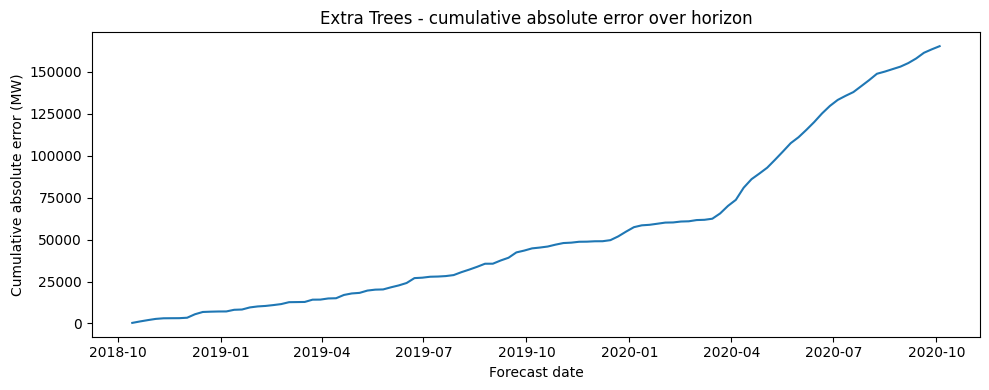


Saved Extra Trees results and forecast.


In [9]:
# ============================================================
# PART 5: Feature-based model - Extra Trees with RECURSIVE multi-step forecasting
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesRegressor

# --- Reload weekly load and temperature data, reuse same fixed origin ---
weekly = pd.read_csv("de_load_weekly.csv", index_col=0, parse_dates=True)
temp_weekly = pd.read_csv("berlin_temperature_weekly.csv", index_col=0, parse_dates=True).iloc[:, 0]

series = weekly["load_mw"]
holiday_days = weekly["holiday_days"]

horizon = 104
train_end_idx = len(series) - horizon

# --- Build a feature table: lagged load values + temperature + holiday count ---
# We use lag_1, lag_2, lag_52 (last week, two weeks ago, same week last year)
# as predictors, since these were the lags the ACF/PACF flagged as important.
def build_feature_table(load, temp, holidays, max_lag=52):
    df = pd.DataFrame({"load": load, "temp": temp, "holiday_days": holidays})
    df["lag_1"] = df["load"].shift(1)
    df["lag_2"] = df["load"].shift(2)
    df["lag_52"] = df["load"].shift(max_lag)
    df = df.dropna()
    return df

feature_table = build_feature_table(series, temp_weekly, holiday_days)

feature_cols = ["lag_1", "lag_2", "lag_52", "temp", "holiday_days"]
target_col = "load"

# --- Re-split into train/test using the SAME fixed origin as other models ---
# (feature_table is shorter than the original series because of the lag_52
# shift, so we align by date rather than by raw row count.)
forecast_origin_date = series.index[train_end_idx - 1]
train_features = feature_table[feature_table.index <= forecast_origin_date]
test_dates = series.index[train_end_idx:]

print("Forecast origin:", forecast_origin_date)
print("Training rows available after lagging:", len(train_features))

# --- Fit the Extra Trees model on the training feature table ---
X_train = train_features[feature_cols]
y_train = train_features[target_col]

et_model = ExtraTreesRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
et_model.fit(X_train, y_train)

# --- RECURSIVE multi-step forecast ---
# At each step, we predict one week ahead using only information that would
# actually be available at that point: our OWN previous predictions for
# lag_1/lag_2, and the true lag_52 value (since that's 52 weeks in the past
# relative to the current step, which is always in the known training data
# for the first year, then rolls into our own earlier predictions after that).
# This is the key mechanism that prevents data leakage: at no point do we
# use an actual test-period load value to predict another test-period value.
history = series.copy()  # running series we extend with our own predictions
predictions = []

for step, forecast_date in enumerate(test_dates):
    lag_1 = history.loc[:forecast_date].iloc[-1]           # last known/predicted value
    lag_2 = history.loc[:forecast_date].iloc[-2]           # two steps back
    lag_52_date_idx = history.index.get_loc(forecast_date) - 52
    lag_52 = history.iloc[lag_52_date_idx]                 # 52 weeks back (real or predicted)

    temp_value = temp_weekly.loc[forecast_date]            # temperature: still "known" (see caveat below)
    holiday_value = holiday_days.loc[forecast_date]        # holidays are known far in advance

    x_step = pd.DataFrame([{
        "lag_1": lag_1, "lag_2": lag_2, "lag_52": lag_52,
        "temp": temp_value, "holiday_days": holiday_value,
    }])[feature_cols]

    pred = et_model.predict(x_step)[0]
    predictions.append(pred)

    # Feed the prediction back into history so the NEXT step's lag_1/lag_2
    # use our own forecast, not the real (unavailable) future value.
    history.loc[forecast_date] = pred

et_forecast = pd.Series(predictions, index=test_dates)
actual_test = series.loc[test_dates]

# --- Plot recursive Extra Trees forecast against actual ---
plt.figure(figsize=(14, 6))
plt.plot(series.index[train_end_idx - 52:train_end_idx], series.iloc[train_end_idx - 52:train_end_idx],
          label="Train (last year shown)", color="black")
plt.plot(actual_test.index, actual_test, label="Actual (test)", color="black", linestyle="--")
plt.plot(et_forecast.index, et_forecast, label="Extra Trees recursive forecast", color="purple")
plt.axvline(series.index[train_end_idx - 1], color="grey", linestyle=":", label="Forecast origin")
plt.legend()
plt.title("Extra Trees recursive multi-step forecast over 104-week horizon")
plt.ylabel("MW")
plt.tight_layout()
plt.show()

# --- Evaluate by horizon block ---
def compute_errors(actual, predicted):
    error = actual.values - predicted.values
    rmse = np.sqrt((error ** 2).mean())
    mae = np.abs(error).mean()
    return rmse, mae

blocks = {
    "Weeks 1-26": slice(0, 26),
    "Weeks 27-52": slice(26, 52),
    "Weeks 53-78": slice(52, 78),
    "Weeks 79-104": slice(78, 104),
    "Full period": slice(0, 104),
}

et_results = []
cumulative_abs_error = np.abs(actual_test.values - et_forecast.values).cumsum()
for block_name, block_slice in blocks.items():
    rmse, mae = compute_errors(actual_test.iloc[block_slice], et_forecast.iloc[block_slice])
    et_results.append({"horizon_block": block_name, "rmse": rmse, "mae": mae})

et_results_df = pd.DataFrame(et_results)
print("\nExtra Trees results by horizon block:")
print(et_results_df)

# --- Feature importance: which lags/covariates matter most ---
importances = pd.Series(et_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nFeature importances:")
print(importances)

# --- Cumulative absolute error over the horizon (for the horizon-degradation figure) ---
plt.figure(figsize=(10, 4))
plt.plot(test_dates, cumulative_abs_error)
plt.title("Extra Trees - cumulative absolute error over horizon")
plt.xlabel("Forecast date")
plt.ylabel("Cumulative absolute error (MW)")
plt.tight_layout()
plt.show()

# --- Save everything for later comparison and the report ---
et_results_df.to_csv("extra_trees_horizon_results.csv", index=False)
et_forecast.to_csv("extra_trees_forecast.csv")
print("\nSaved Extra Trees results and forecast.")

Using device: cuda
Train hours: 32928 Test hours: 17472
Epoch 1/15 - loss: 0.044573
Epoch 2/15 - loss: 0.006899
Epoch 3/15 - loss: 0.002592
Epoch 4/15 - loss: 0.001674
Epoch 5/15 - loss: 0.001232
Epoch 6/15 - loss: 0.000891
Epoch 7/15 - loss: 0.000671
Epoch 8/15 - loss: 0.000595
Epoch 9/15 - loss: 0.000479
Epoch 10/15 - loss: 0.000483
Epoch 11/15 - loss: 0.000430
Epoch 12/15 - loss: 0.000428
Epoch 13/15 - loss: 0.000412
Epoch 14/15 - loss: 0.000389
Epoch 15/15 - loss: 0.000382


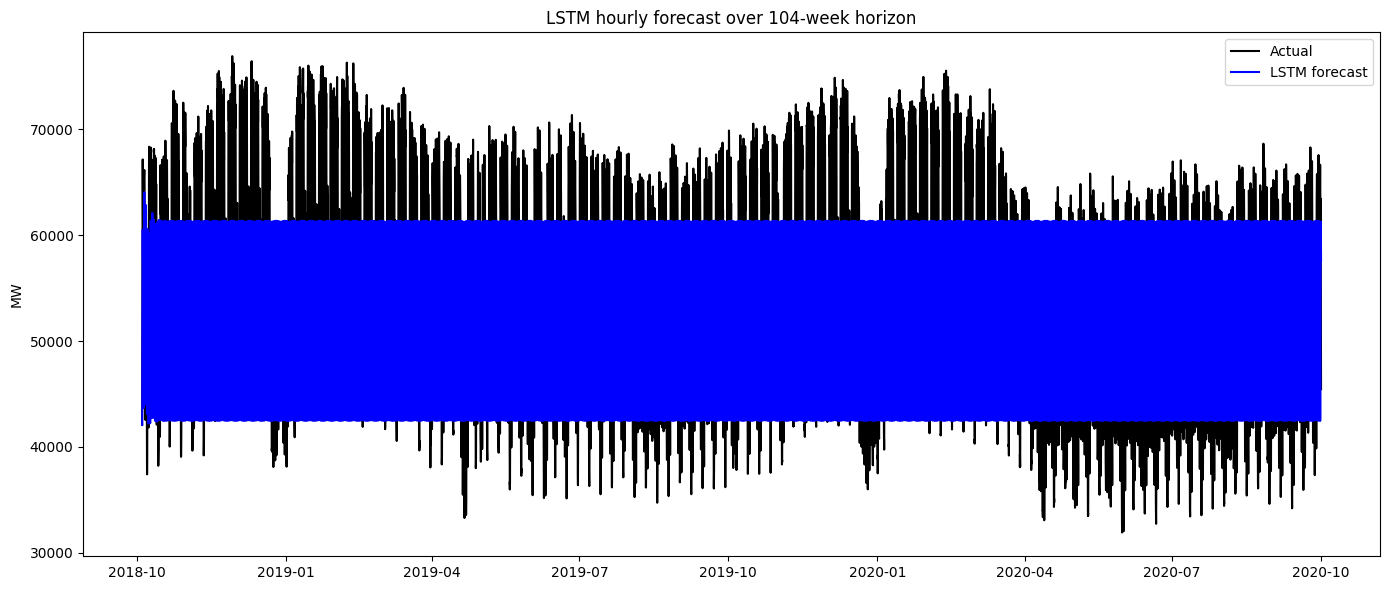

  horizon_block         rmse          mae
0    Weeks 1-26  6332.518793  5736.405920
1   Weeks 27-52  1622.637258  1409.481199
2   Weeks 53-78  5235.655547  4764.918612
3  Weeks 79-104  3805.542347  3414.058331
4   Full period  4599.673562  3831.216015
Saved LSTM results and forecasts.


In [10]:
# ============================================================
# PART 6: LSTM model on hourly data, forecast over equivalent horizon
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- Load hourly data ---
hourly = pd.read_csv("de_load_hourly.csv", index_col=0, parse_dates=True)
load = hourly["load_mw"]

# --- Fixed origin: last 104 weeks = 104*7*24 hours ---
horizon_hours = 104 * 7 * 24
train = load.iloc[:-horizon_hours]
test = load.iloc[-horizon_hours:]

print("Train hours:", len(train), "Test hours:", len(test))

# --- Scale data ---
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
test_scaled = scaler.transform(test.values.reshape(-1, 1))

# --- Build sequences ---
def build_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X), np.array(y)

seq_len = 168  # one week of hourly data
X_train, y_train = build_sequences(train_scaled, seq_len)

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)

# --- LSTM model ---
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

model = LSTMForecaster().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# --- Train ---
batch_size = 256
n_epochs = 15
n_batches = len(X_train_t) // batch_size

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0
    perm = torch.randperm(len(X_train_t))
    for i in range(n_batches):
        idx = perm[i * batch_size:(i + 1) * batch_size]
        xb, yb = X_train_t[idx], y_train_t[idx]
        optimizer.zero_grad()
        pred = model(xb).squeeze()
        loss = criterion(pred, yb.squeeze())
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{n_epochs} - loss: {epoch_loss / n_batches:.6f}")

# --- Recursive forecast over the test horizon ---
model.eval()
history_scaled = list(train_scaled[-seq_len:].flatten())
predictions_scaled = []

with torch.no_grad():
    for step in range(len(test_scaled)):
        seq = torch.tensor(history_scaled[-seq_len:], dtype=torch.float32).reshape(1, seq_len, 1).to(device)
        pred = model(seq).item()
        predictions_scaled.append(pred)
        history_scaled.append(pred)

predictions = scaler.inverse_transform(np.array(predictions_scaled).reshape(-1, 1)).flatten()
lstm_forecast = pd.Series(predictions, index=test.index)

# --- Plot forecast vs actual ---
plt.figure(figsize=(14, 6))
plt.plot(test.index, test, label="Actual", color="black")
plt.plot(lstm_forecast.index, lstm_forecast, label="LSTM forecast", color="blue")
plt.legend()
plt.title("LSTM hourly forecast over 104-week horizon")
plt.ylabel("MW")
plt.tight_layout()
plt.show()

# --- Aggregate to weekly for comparison with other models ---
lstm_weekly_forecast = lstm_forecast.resample("W").mean()
actual_weekly_test = test.resample("W").mean()

def compute_errors(actual, predicted):
    error = actual.values - predicted.values
    rmse = np.sqrt((error ** 2).mean())
    mae = np.abs(error).mean()
    return rmse, mae

blocks = {
    "Weeks 1-26": slice(0, 26),
    "Weeks 27-52": slice(26, 52),
    "Weeks 53-78": slice(52, 78),
    "Weeks 79-104": slice(78, 104),
    "Full period": slice(0, 104),
}

lstm_results = []
for block_name, block_slice in blocks.items():
    a = actual_weekly_test.iloc[block_slice]
    p = lstm_weekly_forecast.iloc[block_slice]
    rmse, mae = compute_errors(a, p)
    lstm_results.append({"horizon_block": block_name, "rmse": rmse, "mae": mae})

lstm_results_df = pd.DataFrame(lstm_results)
print(lstm_results_df)

# --- Save ---
lstm_results_df.to_csv("lstm_horizon_results.csv", index=False)
lstm_forecast.to_csv("lstm_forecast_hourly.csv")
lstm_weekly_forecast.to_csv("lstm_forecast_weekly.csv")
print("Saved LSTM results and forecasts.")

RMSE by horizon block:
horizon_block    Full period    Weeks 1-26   Weeks 27-52   Weeks 53-78  \
model                                                                    
ExtraTrees       2219.562396    775.071063   1415.819960   1644.122155   
LSTM             4599.673562   6332.518793   1622.637258   5235.655547   
SARIMA          55342.415594  59222.587801  53531.065164  57648.389946   
SARIMAX          6445.581699   6411.726349   4720.245140   8801.682599   
drift            5117.957264   5470.484732   2736.615092   3693.045410   
mean             4397.299694   4808.976050   2635.503891   4038.546577   
naive            4459.108546   5871.303657   1721.945288   4828.581948   
seasonal_naive   3006.760812   1711.326077   2142.186239   2067.454305   

horizon_block   Weeks 79-104  
model                         
ExtraTrees       3794.391907  
LSTM             3805.542347  
SARIMA          50546.069565  
SARIMAX          5032.050098  
drift            7329.399461  
mean             55

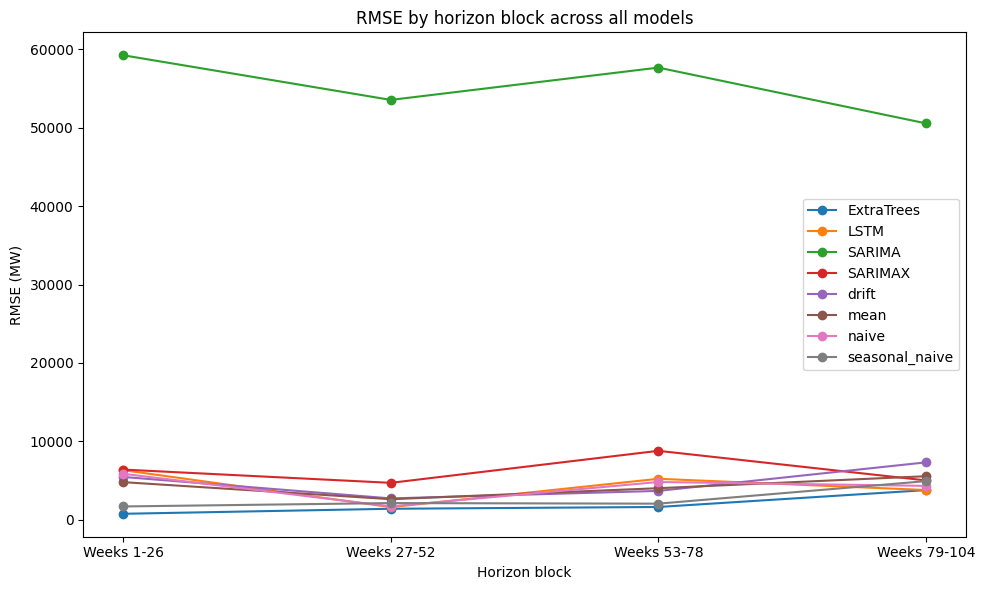

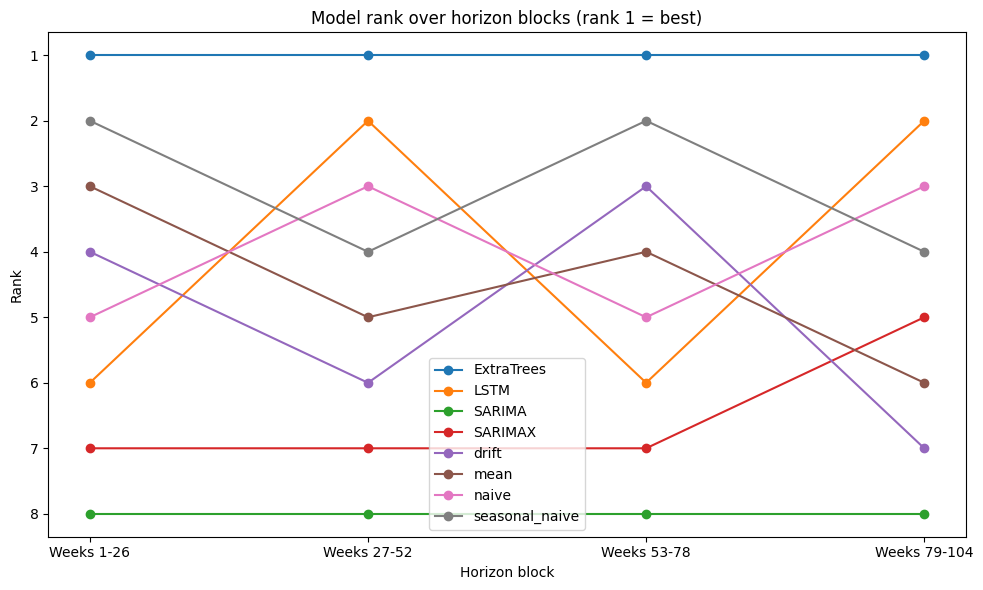


Model stability ranking (lower stability_score = more reliable across full horizon):
                full_period_rmse   rmse_slope  rank_change  stability_score
SARIMAX              6241.426047    -5.759130          0.0         5.759130
naive                4188.915449  -150.578161          0.0       150.578161
mean                 4261.866540   366.943347          2.0       368.943347
LSTM                 4249.088486  -396.791105         -2.0       398.791105
drift                4807.386174   653.317451          0.0       653.317451
ExtraTrees           1907.351271   928.626473          0.0       928.626473
seasonal_naive       2714.403218   960.122859          0.0       960.122859
SARIMA              55237.028119 -2191.222993          0.0      2191.222993

Saved comparison tables.


In [11]:
# ============================================================
# PART 7: Cross-model comparison, horizon-degradation analysis, ranking changes
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load all saved horizon-block results ---
benchmark_results = pd.read_csv("benchmark_horizon_results.csv")
sarima_results = pd.read_csv("sarima_horizon_results.csv")
sarimax_results = pd.read_csv("sarimax_horizon_results.csv")
et_results = pd.read_csv("extra_trees_horizon_results.csv")
lstm_results = pd.read_csv("lstm_horizon_results.csv")

sarima_results["model"] = "SARIMA"
sarimax_results["model"] = "SARIMAX"
et_results["model"] = "ExtraTrees"
lstm_results["model"] = "LSTM"

all_results = pd.concat([
    benchmark_results[["model", "horizon_block", "rmse", "mae"]],
    sarima_results[["model", "horizon_block", "rmse", "mae"]],
    sarimax_results[["model", "horizon_block", "rmse", "mae"]],
    et_results[["model", "horizon_block", "rmse", "mae"]],
    lstm_results[["model", "horizon_block", "rmse", "mae"]],
], ignore_index=True)

# --- Table 1: RMSE by model and horizon block ---
rmse_table = all_results.pivot(index="model", columns="horizon_block", values="rmse")
print("RMSE by horizon block:")
print(rmse_table)

# --- Table 2: model ranking within each horizon block ---
ranking_table = rmse_table.rank(axis=0)
print("\nModel ranking by horizon block (1 = best):")
print(ranking_table)

# --- Error-growth slope: how fast RMSE increases from block 1 to block 4 per model ---
block_order = ["Weeks 1-26", "Weeks 27-52", "Weeks 53-78", "Weeks 79-104"]
slopes = {}
for model in rmse_table.index:
    y = rmse_table.loc[model, block_order].values
    x = np.arange(len(y))
    slope = np.polyfit(x, y, 1)[0]
    slopes[model] = slope

slope_df = pd.Series(slopes, name="rmse_slope_per_block").sort_values()
print("\nError-growth slope (RMSE increase per 26-week block):")
print(slope_df)

# --- First-year vs second-year ranking change ---
rmse_table["first_year"] = rmse_table[["Weeks 1-26", "Weeks 27-52"]].mean(axis=1)
rmse_table["second_year"] = rmse_table[["Weeks 53-78", "Weeks 79-104"]].mean(axis=1)
rmse_table["first_year_rank"] = rmse_table["first_year"].rank()
rmse_table["second_year_rank"] = rmse_table["second_year"].rank()
rmse_table["rank_change"] = rmse_table["second_year_rank"] - rmse_table["first_year_rank"]
print("\nFirst-year vs second-year ranking:")
print(rmse_table[["first_year", "second_year", "first_year_rank", "second_year_rank", "rank_change"]])

# --- Figure: RMSE by 26-week block for all models ---
plt.figure(figsize=(10, 6))
for model in rmse_table.index:
    plt.plot(block_order, rmse_table.loc[model, block_order], marker="o", label=model)
plt.title("RMSE by horizon block across all models")
plt.ylabel("RMSE (MW)")
plt.xlabel("Horizon block")
plt.legend()
plt.tight_layout()
plt.show()

# --- Figure: model ranking changes over the four blocks ---
plt.figure(figsize=(10, 6))
for model in ranking_table.index:
    plt.plot(block_order, ranking_table.loc[model, block_order], marker="o", label=model)
plt.gca().invert_yaxis()
plt.title("Model rank over horizon blocks (rank 1 = best)")
plt.ylabel("Rank")
plt.xlabel("Horizon block")
plt.legend()
plt.tight_layout()
plt.show()

# --- Overall model recommendation: smallest AND most stable deterioration ---
recommendation_table = pd.DataFrame({
    "full_period_rmse": rmse_table[block_order].mean(axis=1),
    "rmse_slope": slope_df,
    "rank_change": rmse_table["rank_change"],
})
recommendation_table["stability_score"] = recommendation_table["rmse_slope"].abs() + recommendation_table["rank_change"].abs()
recommendation_table = recommendation_table.sort_values("stability_score")
print("\nModel stability ranking (lower stability_score = more reliable across full horizon):")
print(recommendation_table)

# --- Save all comparison tables ---
rmse_table.to_csv("model_comparison_rmse_table.csv")
ranking_table.to_csv("model_comparison_ranking_table.csv")
recommendation_table.to_csv("model_comparison_stability_table.csv")
print("\nSaved comparison tables.")